<a href="https://colab.research.google.com/github/Mez-MohamedRafik/cmapss-predictive-maintenance/blob/main/Engine_Failure_RFR_predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# dataset link : https://colab.research.google.com/drive/1LfTb7jGcbNDosP9LXtOd69fzGr4pjaur#scrollTo=09Eo5cNxAxgU
import pandas as pd

file_path = 'train_FD001.txt'


operational_settings = [f"setting_{i}" for i in range(1, 4)]
sensors = [f"sensor_{i}" for i in range(1, 22)]
columns = ["unit_id", "cycle"] + operational_settings + sensors

df_local = pd.read_csv(file_path, sep=r"\s+", header=None, names=columns)

print(df_local.head())

   unit_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0        1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1        1      2     0.0019    -0.0003      100.0    518.67    642.15   
2        1      3    -0.0043     0.0003      100.0    518.67    642.35   
3        1      4     0.0007     0.0000      100.0    518.67    642.35   
4        1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03        392 

In [ ]:
display(df_local)


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [ ]:
df_local.describe()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,...,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [ ]:
print(df_local['sensor_11'].describe())

count    20631.000000
mean        47.541168
std          0.267087
min         46.850000
25%         47.350000
50%         47.510000
75%         47.700000
max         48.530000
Name: sensor_11, dtype: float64


In [ ]:
df = df_local
set_ = [1,5,6,16,18,19]
df.drop([f"sensor_{i}" for i in set_], axis=1, inplace=True, errors='ignore')
print(df.columns)

Index(['unit_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_2',
       'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21'],
      dtype='object')


In [ ]:
df = df_local.copy()

if 'setting_3' in df.columns:
    df = df.drop(columns=['setting_3'])
    print("'setting_3' column dropped successfully.")
else:
    print("'setting_3' column was not found in the DataFrame (already dropped).")

print(df.columns)

'setting_3' column dropped successfully.
Index(['unit_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21'],
      dtype='object')


In [ ]:
max_cycles = df.groupby("unit_id")["cycle"].transform("max")
df["RUL"] = (max_cycles - df["cycle"]).clip(upper=125)

In [ ]:
print(max_cycles)

df['RUL'].describe()

0        192
1        192
2        192
3        192
4        192
        ... 
20626    200
20627    200
20628    200
20629    200
20630    200
Name: cycle, Length: 20631, dtype: int64


,RUL
count,20631.000000
mean,86.829286
std,41.673699
min,0.000000
25%,51.000000
50%,103.000000
75%,125.000000
max,125.000000


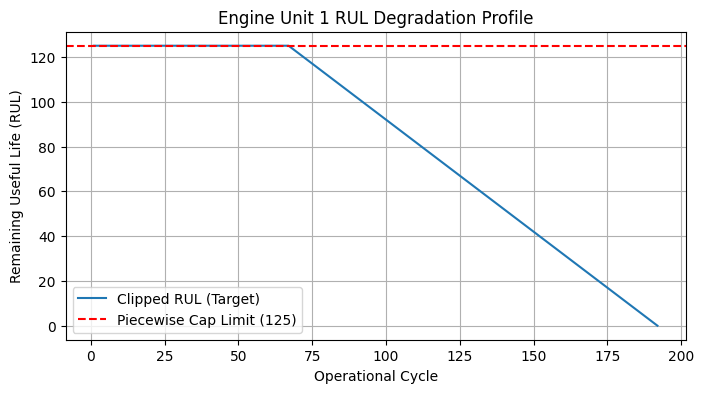

In [ ]:
import matplotlib.pyplot as plt

# Filter data for Engine 1
engine_1 = df[df["unit_id"] == 1]

# Plot RUL across cycles
plt.figure(figsize=(8, 4))
plt.plot(engine_1["cycle"], engine_1["RUL"], label="Clipped RUL (Target)")
plt.axhline(
    y=125,
    color="r",
    linestyle="--",
    label="Piecewise Cap Limit (125)",
)
plt.title("Engine Unit 1 RUL Degradation Profile")
plt.xlabel("Operational Cycle")
plt.ylabel("Remaining Useful Life (RUL)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:

sensor_cols  = []
for c in df.columns:
    if c.startswith("sensor") or c.startswith("setting_"):
        sensor_cols.append(c)
print(sensor_cols)

['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[sensor_cols] = scaler.fit_transform(df[sensor_cols])
df.describe()

,unit_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,0.499490,0.501959,0.443052,0.424746,0.450435,0.566459,0.297957,0.195248,0.0,0.411410,0.580697,0.317871,0.226095,0.451118,0.434221,0.524241,0.546127,86.829286
std,29.227633,68.880990,0.125708,0.244218,0.150618,0.133664,0.151935,0.142527,0.107554,0.099089,0.0,0.158981,0.157261,0.105763,0.098442,0.144306,0.129064,0.140114,0.149476,41.673699
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,26.000000,52.000000,0.413793,0.333333,0.335843,0.331807,0.339467,0.476651,0.227273,0.140761,0.0,0.297619,0.484009,0.235294,0.171870,0.346287,0.333333,0.434109,0.452361,51.000000
50%,52.000000,104.000000,0.500000,0.500000,0.430723,0.415522,0.435348,0.578100,0.287879,0.174684,0.0,0.392857,0.594883,0.308824,0.209516,0.438630,0.416667,0.534884,0.557443,103.000000
75%,77.000000,156.000000,0.586207,0.750000,0.539157,0.508829,0.545324,0.669887,0.363636,0.213991,0.0,0.505952,0.695096,0.382353,0.249613,0.541362,0.500000,0.627907,0.652582,125.000000
max,100.000000,362.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,125.000000


In [ ]:
import numpy as np

def add_rolling_features(df, sensor_cols, window_size = 20):
    df_feat = df.copy()
    for col in sensor_cols:
        df_feat[f"{col}_roll_mean"] = df_feat.groupby("unit_id")[col].transform(lambda x: x.rolling(window=window_size, min_periods=1).mean())
        df_feat[f"{col}_roll_std"] = df_feat.groupby("unit_id")[col].transform(lambda x: x.rolling(window_size, min_periods = 1).std()).fillna(0)
    return df_feat

In [ ]:
df_train_engineered = add_rolling_features(df, sensor_cols , window_size = 20)

# Drop sensor_10 related columns as they have zero variance and were removed from test data
to_drop_sensor_10_cols = ['sensor_10', 'sensor_10_roll_mean', 'sensor_10_roll_std']
df_train_engineered = df_train_engineered.drop(columns=to_drop_sensor_10_cols, errors='ignore')

feature_names = [c for c in df_train_engineered.columns if c not in ["unit_id", "cycle", "RUL", "RUL_raw"]]

In [ ]:
X_train = df_train_engineered[feature_names]
y_train = df_train_engineered["RUL"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=100, max_depth = 15, random_state=42, n_jobs=-1)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_jobs=-1, random_state=42)

In [ ]:
cols = ["unit_id", "cycle"] + [f"setting_{i}" for i in range(1,4)] + [f"sensor_{i}"for i in range(1, 22)]
df_test = pd.read_csv("test_FD001.txt", sep=r"\s+", header=None, names=cols)
df_test.head()

,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130


In [ ]:
to_drop_cols = [c for c in cols if c not in feature_names]
print(to_drop_cols)

['unit_id', 'cycle', 'setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_16', 'sensor_18', 'sensor_19']


In [ ]:
cols_to_keep_for_engineering = ['unit_id', 'cycle']
actual_cols = cols_to_keep_for_engineering + feature_names
print(actual_cols)

['unit_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'setting_1_roll_mean', 'setting_1_roll_std', 'setting_2_roll_mean', 'setting_2_roll_std', 'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_9_roll_mean', 'sensor_9_roll_std', 'sensor_10_roll_mean', 'sensor_10_roll_std', 'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean', 'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std', 'sensor_17_roll_mean', 'sensor_17_roll_std', 'sensor_20_roll_mean', 'sensor_20_roll_std', 'sensor_21_roll_mean', 'sensor_21_roll_std']


In [ ]:

actual_cols_to_drop = [c for c in to_drop_cols if c not in cols_to_keep_for_engineering]
df_test = df_test.drop(columns = actual_cols_to_drop, errors = 'ignore')
df_test[sensor_cols] = scaler.transform(df_test[sensor_cols])
df_test_engineered = add_rolling_features(df_test, sensor_cols, window_size = 20)
print(df_test_engineered.columns)

Index(['unit_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'setting_1_roll_mean',
       'setting_1_roll_std', 'setting_2_roll_mean', 'setting_2_roll_std',
       'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean',
       'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std',
       'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_8_roll_mean',
       'sensor_8_roll_std', 'sensor_9_roll_mean', 'sensor_9_roll_std',
       'sensor_10_roll_mean', 'sensor_10_roll_std', 'sensor_11_roll_mean',
       'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std',
       'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean',
       'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std',
       'sensor_17_roll_mean', 'sensor_17_roll_std', 'sen

In [ ]:
df_test_engineered['sensor_10'].describe()

,sensor_10
count,13096.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


In [ ]:
to_drop__cols = []
for c in df_test_engineered.columns:
    if c.startswith("sensor_10"):
        to_drop__cols.append(c)
print(to_drop__cols)

['sensor_10', 'sensor_10_roll_mean', 'sensor_10_roll_std']


In [ ]:
df_test_engineered = df_test_engineered.drop(columns = to_drop__cols, errors = 'ignore')
print(df_test_engineered.columns)

Index(['unit_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11',
       'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17',
       'sensor_20', 'sensor_21', 'setting_1_roll_mean', 'setting_1_roll_std',
       'setting_2_roll_mean', 'setting_2_roll_std', 'sensor_2_roll_mean',
       'sensor_2_roll_std', 'sensor_3_roll_mean', 'sensor_3_roll_std',
       'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_7_roll_mean',
       'sensor_7_roll_std', 'sensor_8_roll_mean', 'sensor_8_roll_std',
       'sensor_9_roll_mean', 'sensor_9_roll_std', 'sensor_11_roll_mean',
       'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std',
       'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean',
       'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std',
       'sensor_17_roll_mean', 'sensor_17_roll_std', 'sensor_20_roll_mean',
       'sensor_20_roll_std', 'sensor_21_roll_m

In [ ]:
feature_names = [name for name in feature_names if not name.startswith('sensor_10')]
print(feature_names)

['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'setting_1_roll_mean', 'setting_1_roll_std', 'setting_2_roll_mean', 'setting_2_roll_std', 'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean', 'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std', 'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_8_roll_mean', 'sensor_8_roll_std', 'sensor_9_roll_mean', 'sensor_9_roll_std', 'sensor_11_roll_mean', 'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std', 'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean', 'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std', 'sensor_17_roll_mean', 'sensor_17_roll_std', 'sensor_20_roll_mean', 'sensor_20_roll_std', 'sensor_21_roll_mean', 'sensor_21_roll_std']


In [ ]:
#X_test will have thousands of rows (every recorded cycle for every test engine), while your y_test ground truth only has 100 rows. Your code will crash with a shape mismatch error.
#X_test comportera des milliers de lignes (chaque cycle enregistré pour chaque moteur testé), alors que la vérité terrain y_test ne compte que 100 lignes. Votre code provoquera une erreur d'incompatibilité de forme (shape mismatch).

df_test_last = df_test_engineered.groupby("unit_id").last().reset_index()
X_test = df_test_last[feature_names]
y_test_true = pd.read_csv("RUL_FD001.txt", header=None, names=["RUL"])["RUL"].clip(upper = 125)

y_pred = rfr.predict(X_test)



In [ ]:
print(df_test_engineered.columns)


Index(['unit_id', 'cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3',
       'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
       'sensor_17', 'sensor_20', 'sensor_21', 'setting_1_roll_mean',
       'setting_1_roll_std', 'setting_2_roll_mean', 'setting_2_roll_std',
       'sensor_2_roll_mean', 'sensor_2_roll_std', 'sensor_3_roll_mean',
       'sensor_3_roll_std', 'sensor_4_roll_mean', 'sensor_4_roll_std',
       'sensor_7_roll_mean', 'sensor_7_roll_std', 'sensor_8_roll_mean',
       'sensor_8_roll_std', 'sensor_9_roll_mean', 'sensor_9_roll_std',
       'sensor_10_roll_mean', 'sensor_10_roll_std', 'sensor_11_roll_mean',
       'sensor_11_roll_std', 'sensor_12_roll_mean', 'sensor_12_roll_std',
       'sensor_13_roll_mean', 'sensor_13_roll_std', 'sensor_14_roll_mean',
       'sensor_14_roll_std', 'sensor_15_roll_mean', 'sensor_15_roll_std',
       'sensor_17_roll_mean', 'sensor_17_roll_std', 'sen

In [ ]:
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test_true, y_pred))
mae = mean_squared_error(y_test_true, y_pred)
print(f"Test RMSE: {rmse:.2f} cycles")
print(f"Test MAE':{mae:.2f} cycles")

Test RMSE: 20.84 cycles
Test MAE':434.21 cycles


In [ ]:
from sklearn.metrics import mean_squared_error

y_true = np.ravel(y_test_true)
y_pred_flat = np.ravel(y_pred)

rmse = np.sqrt(mean_squared_error(y_test_true, y_pred))
mae = mean_squared_error(y_test_true, y_pred)

print(f"Correct RMSE: {rmse:.2f} cycles")
print(f"Correct MAE: {mae:.2f} cycles")

Correct RMSE: 20.84 cycles
Correct MAE: 434.21 cycles


In [ ]:

from sklearn.metrics import mean_absolute_error, mean_squared_error


y_true_clean = pd.Series(np.array(y_test_true).reshape(-1))
y_pred_clean = pd.Series(np.array(y_pred).reshape(-1))

print("Shape of True target:", y_true_clean.shape)
print("Shape of Predictions:", y_pred_clean.shape)

rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
mae = mean_absolute_error(y_true_clean, y_pred_clean)

print(f"\nCorrected RMSE: {rmse:.2f} cycles")
print(f"Corrected MAE:  {mae:.2f} cycles")

Shape of True target: (100,)
Shape of Predictions: (100,)

Corrected RMSE: 20.84 cycles
Corrected MAE:  14.25 cycles


In [ ]:
"""
Project Overview & Evaluation Flow:
1. Data Processing: Cleaned raw C-MAPSS sensor readings, normalized features,
   and engineered rolling window statistics to capture degradation trends.
2. Inference: Passed test engine data (FD001) at their final recorded flight
   cycles through the trained Random Forest model to predict Remaining Useful Life (RUL).
3. Evaluation: Compared predicted RULs (y_pred) against ground truth labels (RUL_FD001.txt)
   and quantified performance using RMSE and MAE metrics.
"""